# Análise Descritiva das Bases

Este notebook realiza uma análise descritiva das bases de dados do case de sistema de recomendação. Vamos carregar os dados, verificar dimensões, tipos, valores faltantes, distribuições de variáveis numéricas e correlações entre variáveis.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

try:
    import seaborn as sns
    sns_available = True
except ImportError:
    sns_available = False

plt.style.use('seaborn-v0_8')

In [3]:
clientes = pd.read_csv('data/clientes.csv')
contratos_ativos = pd.read_csv('data/contratos_ativos.csv')
interacoes = pd.read_csv('data/interacoes.csv')
produtos = pd.read_csv('data/produtos.csv')

for df, name in [(clientes, 'clientes'), (contratos_ativos, 'contratos_ativos'), (interacoes, 'interacoes'), (produtos, 'produtos')]:
    print(f"{name}: {df.shape}")
    print(df.dtypes)
    print('-' * 40)

clientes: (50000, 23)
id_cliente                       int64
idade                            int64
genero                          object
uf                              object
segmento                        object
score_credito                  float64
renda_mensal                   float64
saldo_medio_conta              float64
qtd_meses_cliente                int64
qtd_produtos_ativos              int64
qtd_transacoes_pix_6m            int64
vlr_total_investimentos        float64
vlr_medio_gasto_cartao         float64
vlr_medio_gasto_alimentacao    float64
vlr_medio_gasto_transporte     float64
vlr_medio_gasto_saude          float64
vlr_medio_gasto_educacao       float64
vlr_medio_gasto_lazer          float64
ind_debito_automatico            int64
qtd_dias_inatividade           float64
vlr_limite_credito             float64
pct_utilizacao_limite          float64
canal_preferencial              object
dtype: object
----------------------------------------
contratos_ativos: (61997, 

In [5]:
def summarize_dataset(df, name):
    print(f"\n# {name}")
    print(f"Dimensões: {df.shape}")
    print('\nTipos de dados:')
    display(df.dtypes)

    missing = df.isna().sum()
    missing_pct = (missing / len(df) * 100).round(2)
    missing_summary = pd.DataFrame({'faltantes': missing, 'pct_faltantes': missing_pct})
    missing_summary = missing_summary.sort_values('pct_faltantes', ascending=False)

    print('\nValores faltantes por coluna:')
    display(missing_summary)

    fig, ax = plt.subplots(figsize=(10, 4))
    missing_summary_nonzero = missing_summary[missing_summary['faltantes'] > 0]
    if not missing_summary_nonzero.empty:
        ax.bar(missing_summary_nonzero.index.astype(str), missing_summary_nonzero['pct_faltantes'], color='tab:orange')
        ax.set_title(f'Percentual de valores faltantes - {name}')
        ax.set_ylabel('Percentual (%)')
        ax.set_xlabel('Coluna')
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()
    else:
        print('Não foram encontrados valores faltantes.')

    print('\nEstatísticas descritivas das variáveis numéricas:')
    display(df.describe(include='number').T)

    print('\nAmostra dos dados:')
    display(df.head())


def plot_histograms(df, name):
    numeric_cols = df.select_dtypes(include='number').columns.tolist()
    if not numeric_cols:
        print(f'Não há colunas numéricas em {name}.')
        return

    n_cols = min(4, len(numeric_cols))
    n_rows = (len(numeric_cols) + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3.5 * n_rows))
    axes = axes.flatten() if hasattr(axes, 'flatten') else [axes]

    for idx, col in enumerate(numeric_cols):
        ax = axes[idx]
        values = df[col].dropna()
        ax.hist(values, bins=30, color='tab:blue', edgecolor='black', alpha=0.85)
        ax.set_title(col)
        ax.set_xlabel(col)
    for idx in range(len(numeric_cols), len(axes)):
        fig.delaxes(axes[idx])

    fig.suptitle(f'Distribuições das variáveis numéricas - {name}', y=1.02)
    plt.tight_layout()
    plt.show()


def plot_correlation(df, name):
    numeric_df = df.select_dtypes(include='number')
    if numeric_df.shape[1] < 2:
        print(f'Não há variáveis numéricas suficientes para correlação em {name}.')
        return

    corr = numeric_df.corr()
    print(f'Correlação de Pearson para {name}:')
    display(corr)

    fig, ax = plt.subplots(figsize=(10, 8))
    if sns_available:
        sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
    else:
        cax = ax.matshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
        fig.colorbar(cax, ax=ax)
        ax.set_xticks(range(len(corr.columns)))
        ax.set_yticks(range(len(corr.index)))
        ax.set_xticklabels(corr.columns, rotation=45, ha='left')
        ax.set_yticklabels(corr.index)
    ax.set_title(f'Matriz de correlação - {name}')
    plt.tight_layout()
    plt.show()


# clientes
Dimensões: (50000, 23)

Tipos de dados:


id_cliente                       int64
idade                            int64
genero                          object
uf                              object
segmento                        object
score_credito                  float64
renda_mensal                   float64
saldo_medio_conta              float64
qtd_meses_cliente                int64
qtd_produtos_ativos              int64
qtd_transacoes_pix_6m            int64
vlr_total_investimentos        float64
vlr_medio_gasto_cartao         float64
vlr_medio_gasto_alimentacao    float64
vlr_medio_gasto_transporte     float64
vlr_medio_gasto_saude          float64
vlr_medio_gasto_educacao       float64
vlr_medio_gasto_lazer          float64
ind_debito_automatico            int64
qtd_dias_inatividade           float64
vlr_limite_credito             float64
pct_utilizacao_limite          float64
canal_preferencial              object
dtype: object


Valores faltantes por coluna:


,faltantes,pct_faltantes
score_credito,1552,3.10
qtd_dias_inatividade,1528,3.06
vlr_medio_gasto_lazer,1521,3.04
vlr_medio_gasto_saude,1508,3.02
renda_mensal,1501,3.00
vlr_medio_gasto_educacao,1453,2.91
vlr_total_investimentos,1439,2.88
uf,0,0.00
segmento,0,0.00
idade,0,0.00


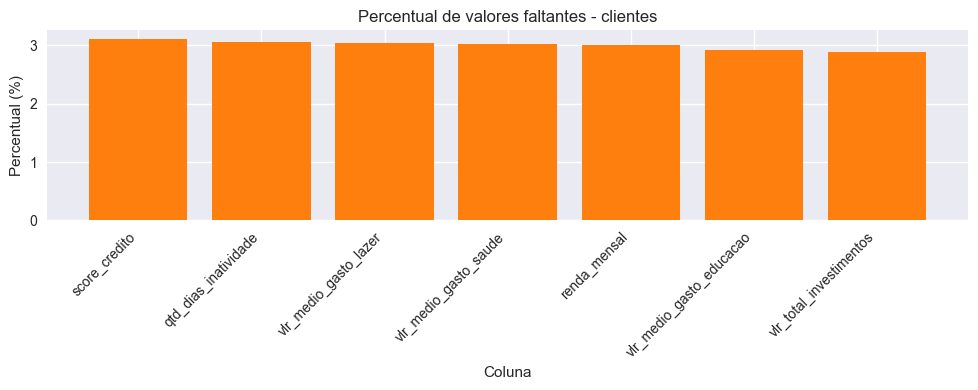


Estatísticas descritivas das variáveis numéricas:


,count,mean,std,min,25%,50%,75%,max
id_cliente,50000.0,25000.500000,14433.901067,1.0000,12500.7500,25000.5000,37500.2500,50000.00
idade,50000.0,38.276660,11.351267,18.0000,30.0000,38.0000,46.0000,80.00
score_credito,48448.0,543.917928,178.095975,50.0000,419.0600,542.8500,675.6925,1000.00
renda_mensal,48499.0,4939.488462,4081.044502,1500.0000,2297.5750,3617.5000,6218.0800,56042.48
saldo_medio_conta,50000.0,7600.531757,8129.777578,150.5000,2611.6975,5072.6950,9597.3175,141333.44
qtd_meses_cliente,50000.0,37.756680,45.108484,1.0000,9.0000,23.0000,49.0000,480.00
qtd_produtos_ativos,50000.0,2.009380,1.748346,0.0000,1.0000,2.0000,3.0000,13.00
qtd_transacoes_pix_6m,50000.0,9.891420,8.719215,0.0000,4.0000,7.0000,13.0000,116.00
vlr_total_investimentos,48561.0,12274.168121,38196.890054,0.0000,0.0000,447.2000,8067.6600,1588884.38
vlr_medio_gasto_cartao,50000.0,1969.868022,1947.935145,150.9200,782.5000,1359.3050,2447.7350,31389.14



Amostra dos dados:


,id_cliente,idade,genero,uf,segmento,score_credito,renda_mensal,saldo_medio_conta,qtd_meses_cliente,qtd_produtos_ativos,...,vlr_medio_gasto_alimentacao,vlr_medio_gasto_transporte,vlr_medio_gasto_saude,vlr_medio_gasto_educacao,vlr_medio_gasto_lazer,ind_debito_automatico,qtd_dias_inatividade,vlr_limite_credito,pct_utilizacao_limite,canal_preferencial
0,1,34,F,PR,basico,617.21,1500.00,2981.16,17,0,...,97.96,139.06,38.89,35.88,114.53,1,12.0,725.95,0.2062,agencia
1,2,58,F,SP,premium,700.98,16620.77,41901.11,21,8,...,705.43,679.74,487.83,147.66,415.77,0,6.0,14116.66,0.1795,web
2,3,46,F,AM,intermediario,696.96,4202.55,916.78,57,2,...,795.14,239.72,69.56,245.75,357.10,1,8.0,4414.47,0.4499,app
3,4,31,M,RS,intermediario,611.78,5969.66,10472.53,58,0,...,704.23,582.83,182.11,21.38,520.29,0,3.0,4992.60,0.3728,app
4,5,56,F,MG,basico,233.49,1816.86,1909.79,32,0,...,49.23,36.48,26.78,9.68,19.63,0,0.0,2139.83,0.5960,app


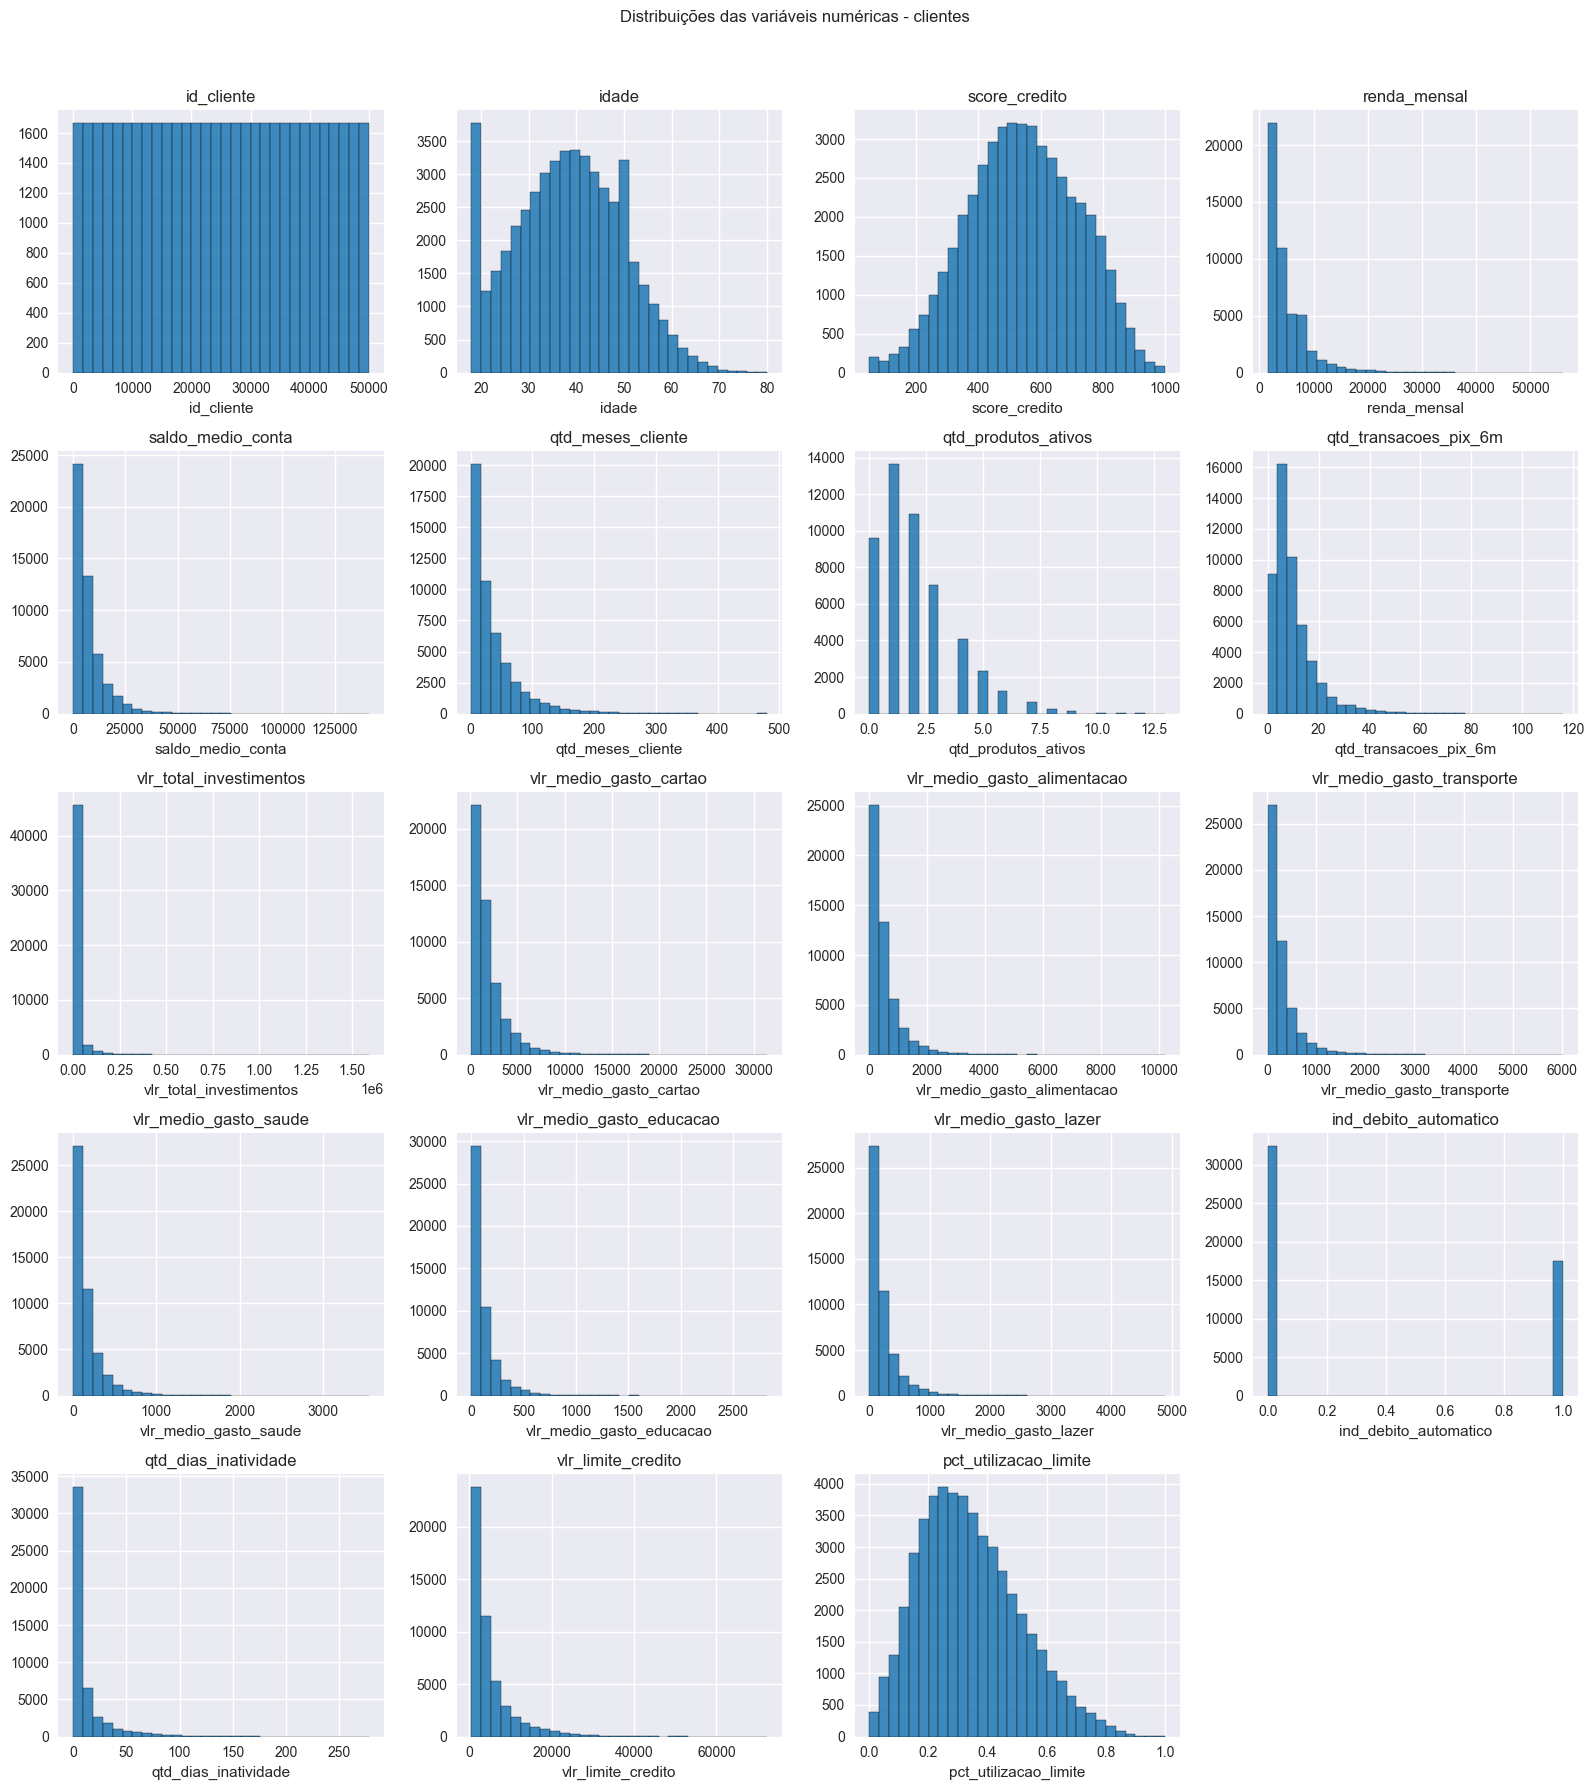

Correlação de Pearson para clientes:


,id_cliente,idade,score_credito,renda_mensal,saldo_medio_conta,qtd_meses_cliente,qtd_produtos_ativos,qtd_transacoes_pix_6m,vlr_total_investimentos,vlr_medio_gasto_cartao,vlr_medio_gasto_alimentacao,vlr_medio_gasto_transporte,vlr_medio_gasto_saude,vlr_medio_gasto_educacao,vlr_medio_gasto_lazer,ind_debito_automatico,qtd_dias_inatividade,vlr_limite_credito,pct_utilizacao_limite
id_cliente,1.000000,-0.002804,-0.004387,-0.005464,-0.004697,-0.006046,-0.006145,-0.005908,-0.004217,0.000140,-0.001909,-0.000438,0.003475,-0.000945,-0.003910,0.002711,-0.000532,0.001096,-0.004244
idade,-0.002804,1.000000,0.251749,0.290633,0.214951,0.152009,0.222297,0.270507,0.178732,0.239835,0.225760,0.210064,0.203363,0.185914,0.205069,0.146346,-0.002855,0.297009,-0.096146
score_credito,-0.004387,0.251749,1.000000,0.499916,0.380390,0.261898,0.386808,0.466552,0.297969,0.414397,0.386697,0.361354,0.350660,0.320830,0.354487,0.254843,0.002323,0.505933,-0.181140
renda_mensal,-0.005464,0.290633,0.499916,1.000000,0.751069,0.301256,0.434899,0.931822,0.358685,0.822515,0.770995,0.721391,0.695748,0.628650,0.698699,0.286416,0.007204,0.590357,-0.171353
saldo_medio_conta,-0.004697,0.214951,0.380390,0.751069,1.000000,0.225018,0.330517,0.697247,0.269073,0.619577,0.580700,0.536983,0.524468,0.469348,0.527754,0.218407,0.007830,0.445533,-0.128425
qtd_meses_cliente,-0.006046,0.152009,0.261898,0.301256,0.225018,1.000000,0.228367,0.281014,0.176053,0.250805,0.234791,0.217177,0.205733,0.190206,0.214708,0.160690,0.000076,0.300564,-0.105442
qtd_produtos_ativos,-0.006145,0.222297,0.386808,0.434899,0.330517,0.228367,1.000000,0.405231,0.261929,0.359524,0.334076,0.315515,0.305072,0.282280,0.303771,0.229025,-0.002740,0.438329,-0.152749
qtd_transacoes_pix_6m,-0.005908,0.270507,0.466552,0.931822,0.697247,0.281014,0.405231,1.000000,0.335496,0.767378,0.720239,0.672690,0.647627,0.589676,0.649620,0.264332,0.004309,0.551153,-0.155308
vlr_total_investimentos,-0.004217,0.178732,0.297969,0.358685,0.269073,0.176053,0.261929,0.335496,1.000000,0.298968,0.276452,0.254277,0.253388,0.232844,0.256682,0.170443,-0.005294,0.362456,-0.096292
vlr_medio_gasto_cartao,0.000140,0.239835,0.414397,0.822515,0.619577,0.250805,0.359524,0.767378,0.298968,1.000000,0.937776,0.878820,0.846531,0.765202,0.853606,0.236720,0.011118,0.489680,-0.142584


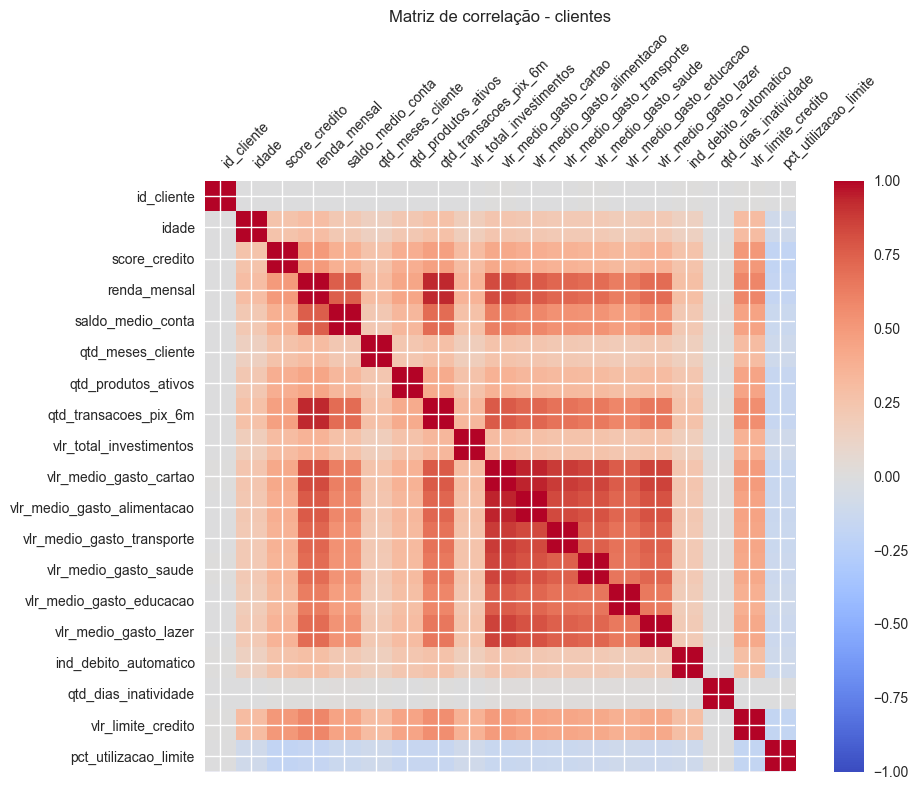


# contratos_ativos
Dimensões: (61997, 5)

Tipos de dados:


id_cliente            int64
produto              object
data_contratacao     object
status               object
canal_contratacao    object
dtype: object


Valores faltantes por coluna:


,faltantes,pct_faltantes
id_cliente,0,0.0
produto,0,0.0
data_contratacao,0,0.0
status,0,0.0
canal_contratacao,0,0.0


Não foram encontrados valores faltantes.

Estatísticas descritivas das variáveis numéricas:


,count,mean,std,min,25%,50%,75%,max
id_cliente,61997.0,25055.630047,14458.747424,1.0,12538.0,25091.0,37604.0,50000.0



Amostra dos dados:


,id_cliente,produto,data_contratacao,status,canal_contratacao
0,1,previdencia,2025-10-23,ativo,app
1,4,seguro_residencial,2025-10-26,cancelado,app
2,4,conta_digital_plus,2025-03-25,ativo,app
3,5,credito_consignado,2024-08-08,ativo,agencia
4,5,cheque_especial,2025-09-04,ativo,app


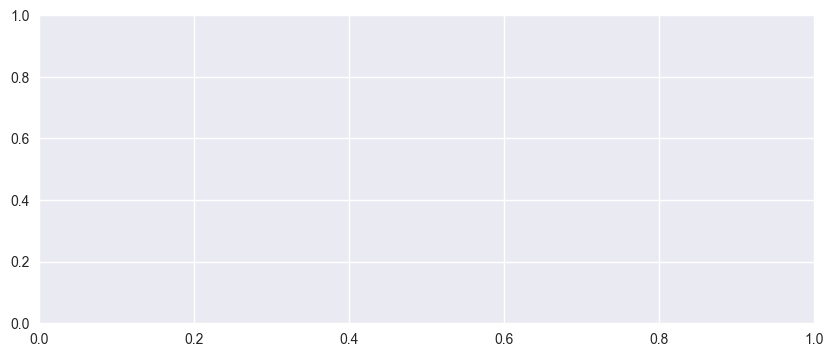

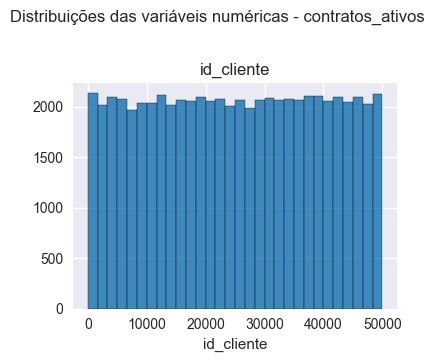

Não há variáveis numéricas suficientes para correlação em contratos_ativos.

# interacoes
Dimensões: (503292, 10)

Tipos de dados:


id_interacao          int64
id_cliente            int64
produto              object
posicao_exibicao      int64
canal                object
clicou                int64
contratou             int64
receita_gerada      float64
timestamp            object
safra                 int64
dtype: object


Valores faltantes por coluna:


,faltantes,pct_faltantes
id_interacao,0,0.0
id_cliente,0,0.0
produto,0,0.0
posicao_exibicao,0,0.0
canal,0,0.0
clicou,0,0.0
contratou,0,0.0
receita_gerada,0,0.0
timestamp,0,0.0
safra,0,0.0


Não foram encontrados valores faltantes.

Estatísticas descritivas das variáveis numéricas:


,count,mean,std,min,25%,50%,75%,max
id_interacao,503292.0,251646.500000,145288.030178,1.0,125823.75,251646.5,377469.25,503292.00
id_cliente,503292.0,25004.816687,14441.914338,1.0,12478.00,25008.0,37523.00,50000.00
posicao_exibicao,503292.0,6.304324,5.405020,1.0,2.00,4.0,10.00,20.00
clicou,503292.0,0.093443,0.291052,0.0,0.00,0.0,0.00,1.00
contratou,503292.0,0.008979,0.094331,0.0,0.00,0.0,0.00,1.00
receita_gerada,503292.0,0.997509,13.483607,0.0,0.00,0.0,0.00,533.95
safra,503292.0,202456.442153,50.133351,202401.0,202407.00,202412.0,202507.00,202512.00



Amostra dos dados:


,id_interacao,id_cliente,produto,posicao_exibicao,canal,clicou,contratou,receita_gerada,timestamp,safra
0,1,45719,previdencia,1,push_notification,0,0,0.0,2024-01-22 20:36:00,202401
1,2,46225,conta_digital_plus,1,app_home,0,0,0.0,2024-01-24 14:49:00,202401
2,3,38294,cartao_platinum,5,app_home,0,0,0.0,2024-01-13 10:48:00,202401
3,4,23592,investimento_lci_lca,16,email,0,0,0.0,2024-01-14 14:42:00,202401
4,5,24185,credito_pessoal,17,app_home,0,0,0.0,2024-01-15 11:00:00,202401


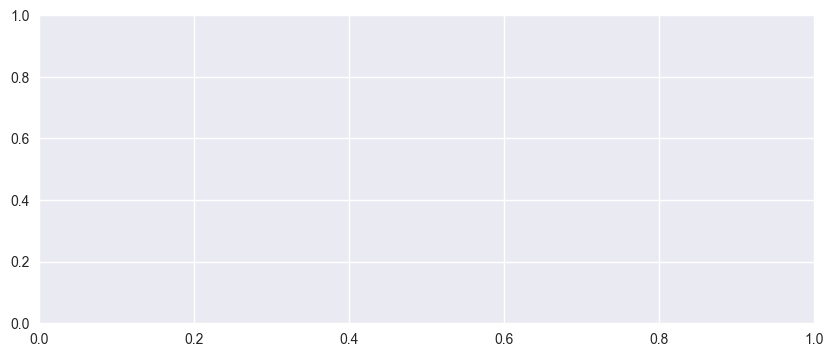

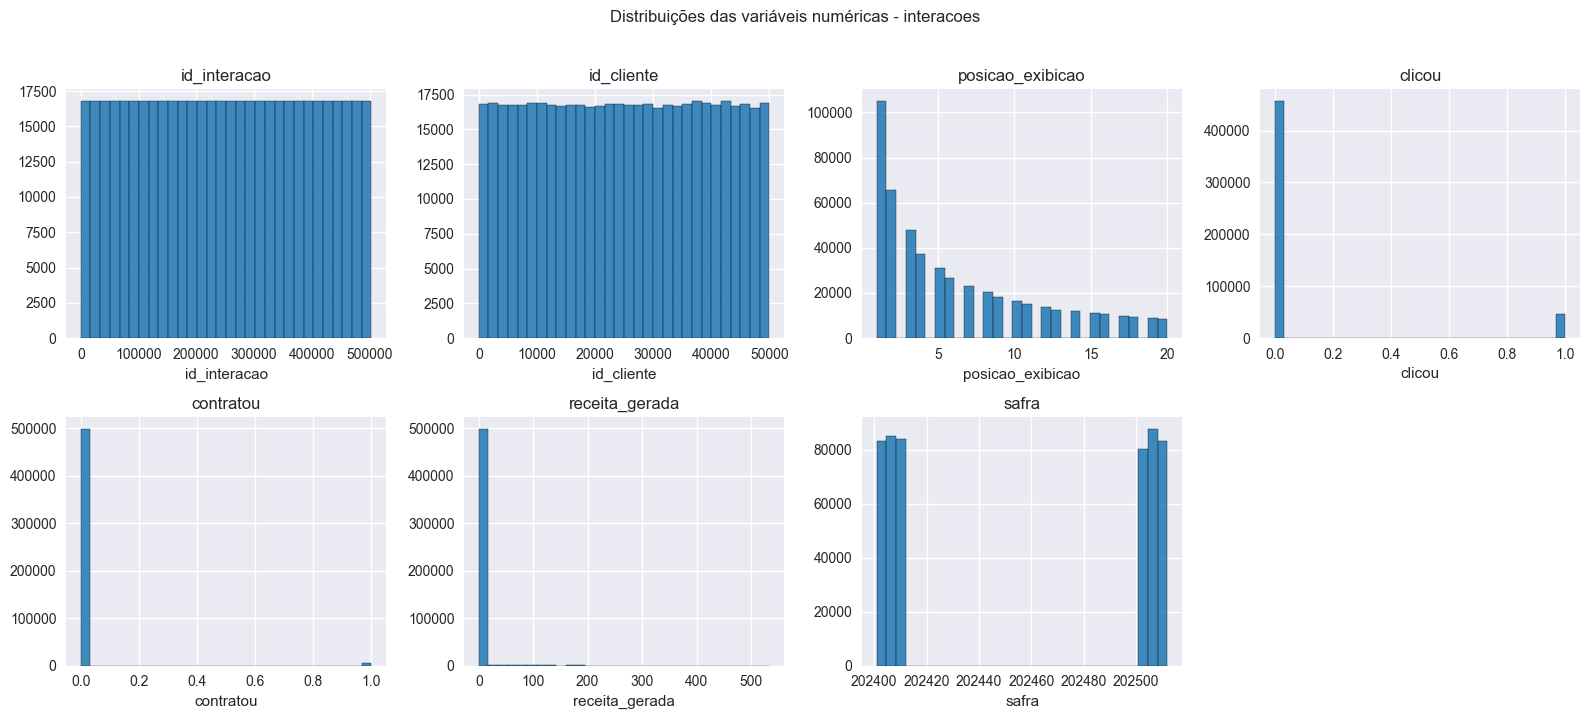

Correlação de Pearson para interacoes:


,id_interacao,id_cliente,posicao_exibicao,clicou,contratou,receita_gerada,safra
id_interacao,1.000000,0.002268,0.000689,-0.013718,-0.004026,-0.005172,0.898056
id_cliente,0.002268,1.000000,-0.000024,-0.002608,-0.000328,0.000598,0.003812
posicao_exibicao,0.000689,-0.000024,1.000000,-0.210501,-0.076320,-0.059842,0.001033
clicou,-0.013718,-0.002608,-0.210501,1.000000,0.296479,0.230428,-0.015503
contratou,-0.004026,-0.000328,-0.076320,0.296479,1.000000,0.777216,-0.006464
receita_gerada,-0.005172,0.000598,-0.059842,0.230428,0.777216,1.000000,-0.005820
safra,0.898056,0.003812,0.001033,-0.015503,-0.006464,-0.005820,1.000000


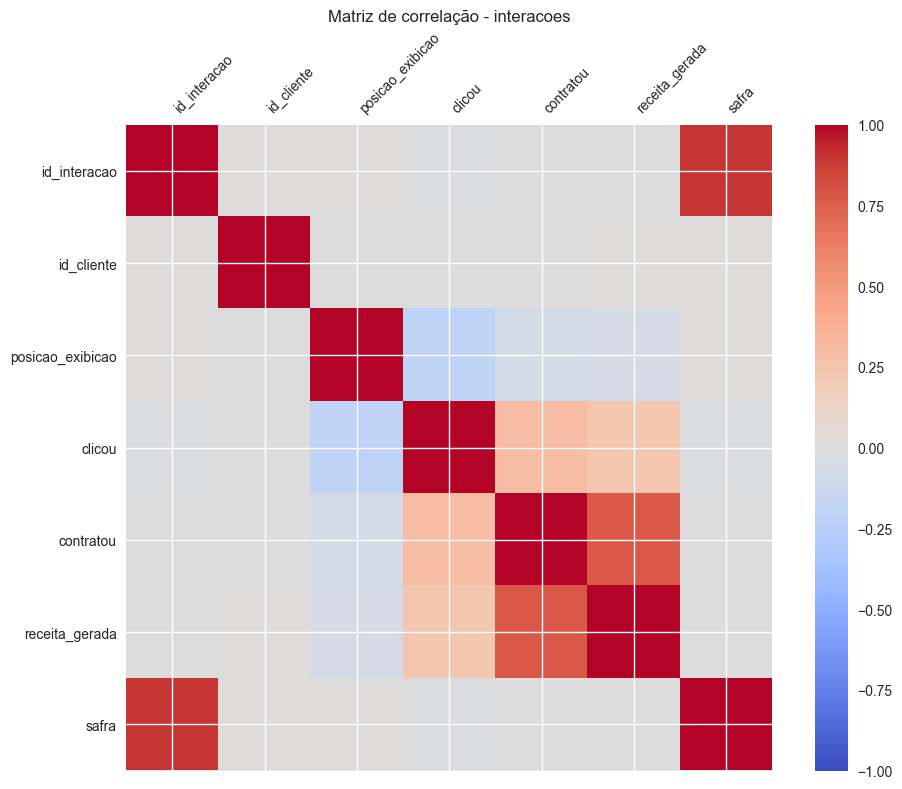


# produtos
Dimensões: (20, 6)

Tipos de dados:


produto             object
categoria           object
receita_media      float64
custo_aquisicao    float64
margem             float64
publico_alvo        object
dtype: object


Valores faltantes por coluna:


,faltantes,pct_faltantes
produto,0,0.0
categoria,0,0.0
receita_media,0,0.0
custo_aquisicao,0,0.0
margem,0,0.0
publico_alvo,0,0.0


Não foram encontrados valores faltantes.

Estatísticas descritivas das variáveis numéricas:


,count,mean,std,min,25%,50%,75%,max
receita_media,20.0,116.0000,107.808309,20.00,43.7500,87.50,135.00,450.00
custo_aquisicao,20.0,16.4000,14.280646,3.00,7.5000,11.00,20.50,55.00
margem,20.0,0.8535,0.020590,0.82,0.8375,0.85,0.87,0.89



Amostra dos dados:


,produto,categoria,receita_media,custo_aquisicao,margem,publico_alvo
0,cartao_platinum,cartao,45.0,8.0,0.82,Clientes com volume medio-alto de gastos mensa...
1,cartao_black,cartao,120.0,18.0,0.85,Clientes ultra-premium com alto volume de gast...
2,credito_pessoal,credito,210.0,35.0,0.83,Clientes com necessidade de credito e bom score
3,credito_consignado,credito,180.0,28.0,0.84,Clientes com renda comprovada via folha de pag...
4,cheque_especial,credito,90.0,12.0,0.87,Clientes que precisam de credito emergencial d...


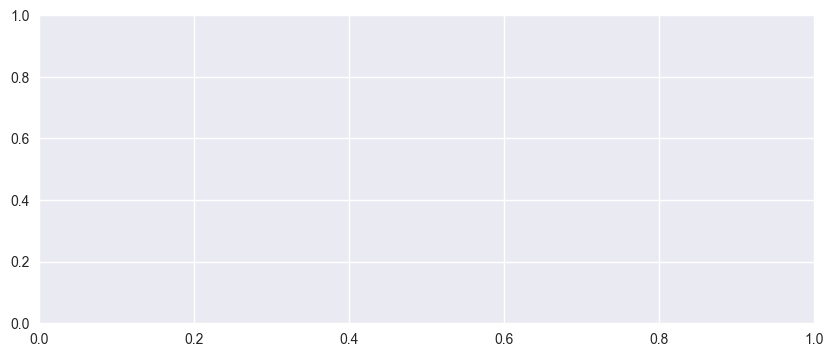

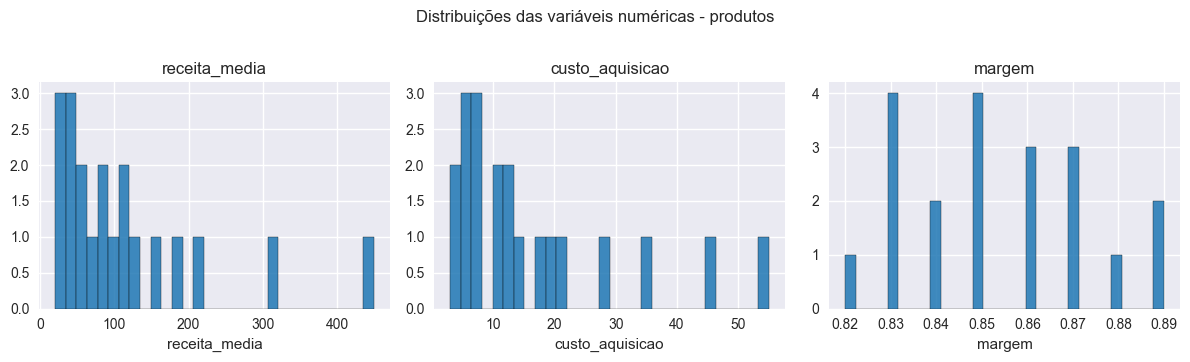

Correlação de Pearson para produtos:


,receita_media,custo_aquisicao,margem
receita_media,1.000000,0.984108,0.269824
custo_aquisicao,0.984108,1.000000,0.136395
margem,0.269824,0.136395,1.000000


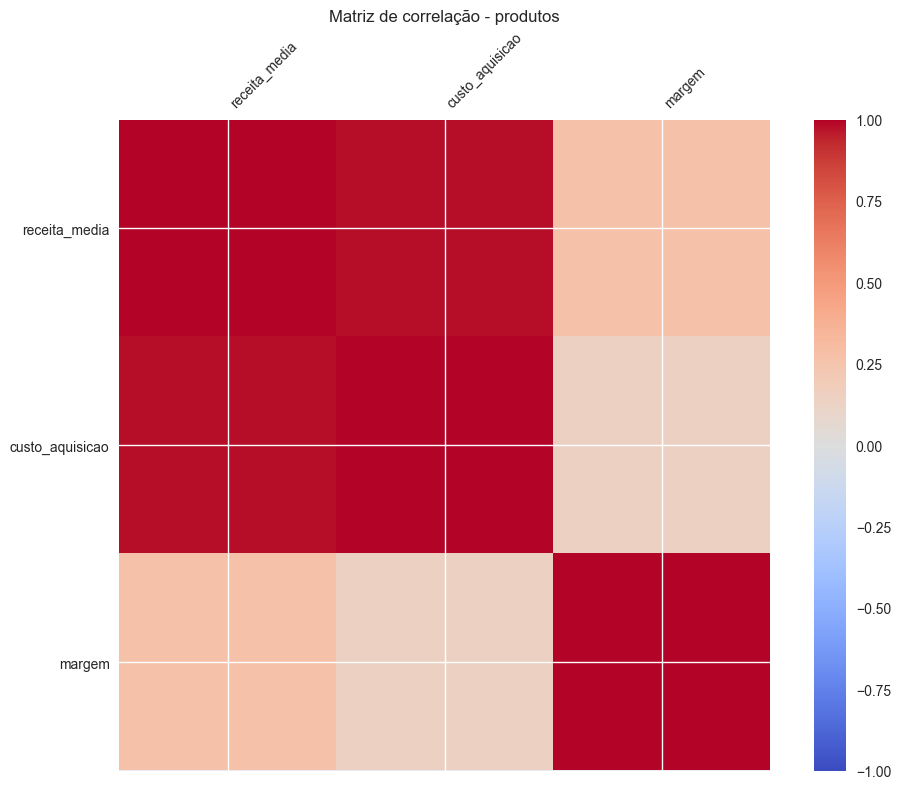

In [6]:
for df, name in [(clientes, 'clientes'), (contratos_ativos, 'contratos_ativos'), (interacoes, 'interacoes'), (produtos, 'produtos')]:
    summarize_dataset(df, name)
    plot_histograms(df, name)
    plot_correlation(df, name)
